#  Entrega 1 — Pré-processamento e Análise de Sentimentos
**Disciplina:** PII 3  
**Objetivo:** Aplicar técnicas de limpeza, padronização e análise de sentimentos em avaliações de clientes de um marketplace, com o objetivo final de classificar/estimar a nota (1–5) com base apenas no texto do comentário.

---
> **Fluxo do notebook:**  
> `Etapa 1 – Tipagem` → `Etapa 2 – Tratamento` → `Etapa 3 – Análise de Sentimento` → `Etapa 4 – Interpretação dos Resultados`


##  Instalação das Bibliotecas
Antes de qualquer coisa, instalamos todas as dependências necessárias para o projeto.  
- **vaderSentiment / nltk**: análise de sentimento baseada em léxico (dicionário de palavras com pontuações)  
- **textblob**: análise de sentimento mais simples, também baseada em léxico  
- **transformers / torch**: modelos de linguagem modernos baseados em redes neurais (BERT)  
- **pysentimiento**: wrapper do BERT treinado especificamente para português  


In [1]:
#!pip install vaderSentiment nltk textblob -q
#!pip install transformers torch -q
#!pip install pysentimiento -q

## Importação das Bibliotecas

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# NLTK / VADER
import nltk
nltk.download('vader_lexicon', quiet=True)
from nltk.sentiment import SentimentIntensityAnalyzer

# TextBlob
from textblob import TextBlob

# Sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

print("Todas as bibliotecas importadas com sucesso!")

Todas as bibliotecas importadas com sucesso!


##  Carregamento dos Dados
Carregamos as tabelas do marketplace. A tabela principal para este projeto é **`avaliacoes`**, pois contém os comentários (`review_comment_message`) e as notas (`review_score`) que queremos prever.


In [3]:
df_avaliacoes   = pd.read_csv('avaliacoes.csv')
df_clientes     = pd.read_csv('clientes.csv')
df_pedidos      = pd.read_csv('pedidos.csv')
df_produtos     = pd.read_csv('produtos.csv')
df_pagamentos   = pd.read_csv('pagamentos.csv')
df_itens_pedidos = pd.read_csv('itens_pedidos.csv')

print(f"Avaliações carregadas: {df_avaliacoes.shape[0]:,} linhas × {df_avaliacoes.shape[1]} colunas")
df_avaliacoes.head(3)

Avaliações carregadas: 99,224 linhas × 7 colunas


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24


---
# Etapa 1 — Tipagem de Dados 

**O que fazemos aqui?**  
Identificamos os tipos de cada coluna e corrigimos aquelas que estão erradas.  
Dados bem tipados são essenciais porque:
- Funções de data precisam que a coluna seja `datetime`, não `object`
- Modelos de machine learning não aceitam strings onde esperamos números
- Colunas categóricas economizam memória quando tipadas corretamente

**Classificação esperada das colunas da tabela `avaliacoes`:**

| Coluna | Tipo esperado | Motivo |
|--------|--------------|--------|
| `review_id` | string | identificador, sem operações numéricas |
| `order_id` | string | identificador, sem operações numéricas |
| `review_score` | int | nota de 1 a 5, variável-alvo numérica |
| `review_comment_title` | string | texto livre |
| `review_comment_message` | string | texto livre — coluna principal |
| `review_creation_date` | datetime | data, permite cálculos temporais |
| `review_answer_timestamp` | datetime | data, permite cálculos temporais |


In [4]:
# --- Verificar tipos originais ---
print("=== Tipos originais das colunas ===")
print(df_avaliacoes.dtypes)
print()

# --- Verificar colunas com tipagem incorreta ---
print("=== Primeiros valores da coluna de datas (antes da conversão) ===")
print(df_avaliacoes[['review_creation_date', 'review_answer_timestamp']].head(3))

=== Tipos originais das colunas ===
review_id                  object
order_id                   object
review_score                int64
review_comment_title       object
review_comment_message     object
review_creation_date       object
review_answer_timestamp    object
dtype: object

=== Primeiros valores da coluna de datas (antes da conversão) ===
  review_creation_date review_answer_timestamp
0  2018-01-18 00:00:00     2018-01-18 21:46:59
1  2018-03-10 00:00:00     2018-03-11 03:05:13
2  2018-02-17 00:00:00     2018-02-18 14:36:24


In [5]:
# --- Corrigindo os tipos ---

# IDs: string (não são números, não se somam nem ordenam)
df_avaliacoes['review_id']  = df_avaliacoes['review_id'].astype('string')
df_avaliacoes['order_id']   = df_avaliacoes['order_id'].astype('string')

# Textos livres: string
df_avaliacoes['review_comment_title']   = df_avaliacoes['review_comment_title'].astype('string')
df_avaliacoes['review_comment_message'] = df_avaliacoes['review_comment_message'].astype('string')

# Nota: inteiro (valores de 1 a 5)
df_avaliacoes['review_score'] = pd.to_numeric(df_avaliacoes['review_score'], errors='coerce').astype('Int64')

# Datas: datetime — permite calcular diferença entre datas, filtrar por período, etc.
df_avaliacoes['review_creation_date']    = pd.to_datetime(df_avaliacoes['review_creation_date'],    errors='coerce')
df_avaliacoes['review_answer_timestamp'] = pd.to_datetime(df_avaliacoes['review_answer_timestamp'], errors='coerce')

print("=== Tipos após correção ===")
print(df_avaliacoes.dtypes)

=== Tipos após correção ===
review_id                  string[python]
order_id                   string[python]
review_score                        Int64
review_comment_title       string[python]
review_comment_message     string[python]
review_creation_date       datetime64[ns]
review_answer_timestamp    datetime64[ns]
dtype: object


In [6]:
# --- Confirmar que review_score está dentro do intervalo esperado (1–5) ---
print("Valores únicos de review_score:", sorted(df_avaliacoes['review_score'].dropna().unique()))
print()
print("Distribuição da nota (variável-alvo):")
print(df_avaliacoes['review_score'].value_counts().sort_index())

Valores únicos de review_score: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Distribuição da nota (variável-alvo):
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: Int64


**Interpretação:**  
Os valores de `review_score` estão corretamente no intervalo de 1 a 5, sem anomalias. A nota **5 é a mais frequente**, o que indica que a base é desbalanceada — os clientes tendem a dar notas extremas (muito satisfeitos ou muito insatisfeitos).


---
# Etapa 2 — Tratamento de Dados 

**O que fazemos aqui?**  
Limpamos e padronizamos os dados para que a análise de sentimento seja mais precisa.  
Dados sujos produzem análises distorcidas — "lixo entra, lixo sai" (*garbage in, garbage out*).

**Passos desta etapa:**
1. Verificar e tratar **valores nulos**
2. Remover **duplicatas**
3. **Padronizar** o texto (minúsculas, espaços extras)
4. **Limpar** os comentários (pontuação, caracteres especiais)
5. Criar a coluna `comentario` unificando título + mensagem


In [7]:
# --- 2.1 Diagnóstico de nulos ---
print("=== Valores nulos por coluna ===")
nulos = df_avaliacoes.isnull().sum()
perc  = (nulos / len(df_avaliacoes) * 100).round(2)
pd.DataFrame({'Nulos': nulos, '% do total': perc})[nulos > 0]

=== Valores nulos por coluna ===


,Nulos,% do total
review_comment_title,87656,88.34
review_comment_message,58247,58.70


**Atenção:** As colunas `review_comment_title` e `review_comment_message` possuem muitos nulos porque **nem todo cliente escreve um comentário** — a nota é obrigatória, o texto é opcional. Vamos preencher os nulos com string vazia e tratar isso na análise.


In [8]:
# --- 2.2 Preencher nulos nas colunas de texto com string vazia ---
# Justificativa: NaN em strings causa erros nas funções de processamento de texto.
# String vazia é o equivalente semântico correto: "cliente não escreveu nada".

df_avaliacoes['review_comment_title']   = df_avaliacoes['review_comment_title'].fillna('').astype(str)
df_avaliacoes['review_comment_message'] = df_avaliacoes['review_comment_message'].fillna('').astype(str)

print("Nulos após preenchimento:")
print(df_avaliacoes[['review_comment_title', 'review_comment_message']].isnull().sum())

Nulos após preenchimento:
review_comment_title      0
review_comment_message    0
dtype: int64


In [9]:
# --- 2.3 Remover duplicatas ---
# Uma mesma avaliação duplicada distorceria os resultados da análise.
antes = len(df_avaliacoes)
df_avaliacoes = df_avaliacoes.drop_duplicates(subset='review_id')
depois = len(df_avaliacoes)
print(f"Linhas antes: {antes:,}  →  Após remoção de duplicatas: {depois:,}  (removidas: {antes - depois})")

Linhas antes: 99,224  →  Após remoção de duplicatas: 98,410  (removidas: 814)


In [10]:
# --- 2.4 Padronização textual ---
# Convertemos para minúsculas e removemos espaços extras nas bordas.
# Motivo: "Ótimo" e "ótimo" devem ser tratados como a mesma palavra pelos analisadores.

import re

def limpar_texto(texto):
    texto = str(texto)
    texto = texto.lower()                          # minúsculas
    texto = texto.strip()                          # espaços nas bordas
    texto = re.sub(r'\s+', ' ', texto)             # múltiplos espaços → um só
    texto = re.sub(r'[^\w\sáéíóúâêîôûãõàèìòùç]', ' ', texto)  # remove pontuação excessiva
    return texto

df_avaliacoes['titulo_limpo']     = df_avaliacoes['review_comment_title'].apply(limpar_texto)
df_avaliacoes['comentario_limpo'] = df_avaliacoes['review_comment_message'].apply(limpar_texto)

print("Exemplo de limpeza:")
for i in range(3):
    msg_orig = df_avaliacoes['review_comment_message'].iloc[i]
    msg_limp = df_avaliacoes['comentario_limpo'].iloc[i]
    if msg_orig.strip():
        print(f"  Original : {msg_orig[:80]}")
        print(f"  Limpo    : {msg_limp[:80]}")
        print()

Exemplo de limpeza:


In [11]:
# --- 2.5 Criar coluna unificada 'comentario' ---
# Combinamos título + mensagem para aproveitar o máximo de informação textual.
# Se a mensagem estiver vazia, usamos só o título, e vice-versa.

def unir_comentario(row):
    titulo  = str(row['titulo_limpo']).strip()
    mensagem = str(row['comentario_limpo']).strip()
    if titulo and mensagem:
        return titulo + ' ' + mensagem
    return titulo or mensagem

df_avaliacoes['comentario'] = df_avaliacoes.apply(unir_comentario, axis=1)

# Estatísticas da coluna final
com_texto = (df_avaliacoes['comentario'].str.strip() != '').sum()
sem_texto = (df_avaliacoes['comentario'].str.strip() == '').sum()
print(f"Avaliações COM comentário : {com_texto:,} ({com_texto/len(df_avaliacoes)*100:.1f}%)")
print(f"Avaliações SEM comentário : {sem_texto:,} ({sem_texto/len(df_avaliacoes)*100:.1f}%)")

Avaliações COM comentário : 42,251 (42.9%)
Avaliações SEM comentário : 56,159 (57.1%)


## Total da base após a remoção dos nulos

In [12]:
# Remove as linhas vazias e também aquelas que só contêm espaços em branco
df_avaliacoes = df_avaliacoes[df_avaliacoes['comentario'].str.strip() != ""]

# Opcional: Para confirmar quantas linhas sobraram no seu dataset
print(f"Total de linhas após remover os vazios: {df_avaliacoes.shape[0]}")

Total de linhas após remover os vazios: 42251


In [13]:
# --- 2.6 Adicionar coluna de tamanho do comentário ---
df_avaliacoes['tamanho_comentario'] = df_avaliacoes['comentario'].apply(len)

print("=== Base de dados final após tratamento ===")
df_avaliacoes[['review_score', 'comentario', 'tamanho_comentario']].describe(include='all')

=== Base de dados final após tratamento ===


,review_score,comentario,tamanho_comentario
count,42251.0,42251,42251.000000
unique,<NA>,35329,NaN
top,<NA>,muito bom,NaN
freq,<NA>,554,NaN
mean,3.705474,NaN,68.293792
std,1.602726,NaN,54.533820
min,1.0,NaN,1.000000
25%,2.0,NaN,27.000000
50%,5.0,NaN,53.000000
75%,5.0,NaN,94.000000


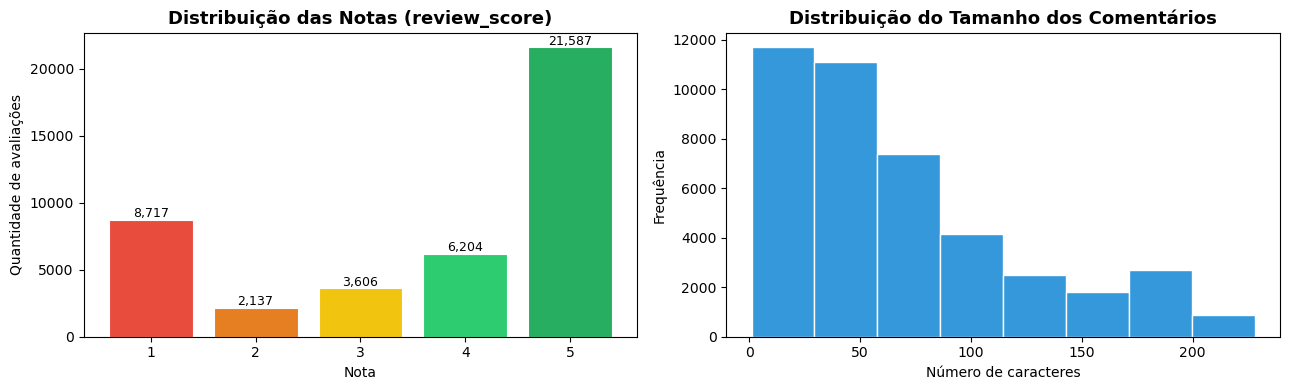

Figura salva.


In [14]:
# --- Visualização: distribuição da nota ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Gráfico 1: distribuição da nota
contagem = df_avaliacoes['review_score'].value_counts().sort_index()
cores = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
axes[0].bar(contagem.index.astype(str), contagem.values, color=cores, edgecolor='white', linewidth=0.8)
axes[0].set_title('Distribuição das Notas (review_score)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Nota')
axes[0].set_ylabel('Quantidade de avaliações')
for i, v in enumerate(contagem.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=9)

# Gráfico 2: tamanho dos comentários
df_com = df_avaliacoes[df_avaliacoes['tamanho_comentario'] > 0]
axes[1].hist(df_com['tamanho_comentario'], bins=8, color='#3498db', edgecolor='white')
axes[1].set_title('Distribuição do Tamanho dos Comentários', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Número de caracteres')
axes[1].set_ylabel('Frequência')

plt.tight_layout()
plt.savefig('etapa2_distribuicoes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura salva.")

**Interpretação:**  
- A distribuição de notas é fortemente **assimétrica à direita** — nota 5 domina. Isso é comum em marketplaces: clientes satisfeitos e insatisfeitos costumam comentar mais.  
- Os comentários têm em sua maioria menos de 200 caracteres — textos curtos, o que é um desafio para os modelos de NLP.


In [15]:
from scipy.stats import spearmanr

corr, p = spearmanr(
    df_com['review_score'],
    df_com['tamanho_comentario']
)

print(f'Correlação de Spearman: {corr:.3f}')
print(f'P-valor: {p:.5f}')

Correlação de Spearman: -0.347
P-valor: 0.00000


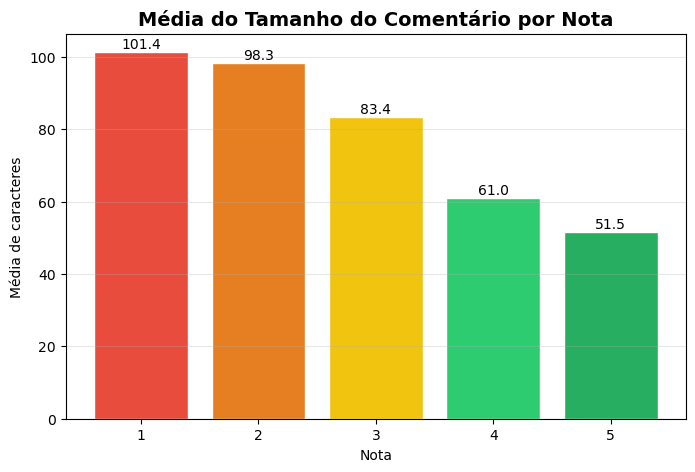

In [16]:
# Média de caracteres por nota
media_tamanho = (
    df_com
    .groupby('review_score')['tamanho_comentario']
    .mean()
)

plt.figure(figsize=(8,5))

bars = plt.bar(
    media_tamanho.index.astype(str),
    media_tamanho.values,
    color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60'],
    edgecolor='white'
)

plt.title('Média do Tamanho do Comentário por Nota',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Nota')
plt.ylabel('Média de caracteres')

# Valores acima das barras
for bar in bars:
    altura = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        altura + 1,
        f'{altura:.1f}',
        ha='center'
    )

plt.grid(axis='y', alpha=0.3)
plt.show()

---
# Etapa 3 — Análise de Sentimento 

**O que é análise de sentimento?**  
É a tarefa de identificar automaticamente se um texto expressa uma opinião **positiva**, **negativa** ou **neutra**.

**Por que usamos múltiplas bibliotecas?**  
Cada biblioteca usa uma abordagem diferente. Comparar os resultados nos ajuda a entender as limitações de cada uma e escolher a melhor para o nosso contexto.

| Biblioteca | Abordagem | Língua original |
|-----------|-----------|-----------------|
| **VADER** | Léxico + regras heurísticas | Inglês |
| **TextBlob** | Léxico estatístico | Inglês |
| **Transformers (BERT)** | Rede neural profunda, fine-tuned para PT-BR | Português ✅ |

> ⚠️ **Limitação importante:** VADER e TextBlob foram criados para inglês. Aplicados a textos em português, tendem a classificar a maioria como "neutro" — não porque o texto é neutro, mas porque as palavras não estão no dicionário deles.


## 3.1 VADER (Valence Aware Dictionary and sEntiment Reasoner)

**Como funciona:** O VADER possui um dicionário onde cada palavra tem uma pontuação de valência (positiva ou negativa). Ele também considera regras como letras maiúsculas, pontuação (!!) e modificadores ("muito bom" vs "bom"). Retorna um score `compound` entre -1 e +1.

**Conversão para nota 1–5:**
- `compound ≤ -0.6` → **1** (muito negativo)
- `-0.6 < compound ≤ -0.2` → **2** (negativo)
- `-0.2 < compound ≤ 0.2` → **3** (neutro)
- `0.2 < compound ≤ 0.6` → **4** (positivo)
- `compound > 0.6` → **5** (muito positivo)


In [17]:
sid = SentimentIntensityAnalyzer()

def score_vader(texto):
    texto = str(texto).strip()
    if not texto:
        return 0.0
    return sid.polarity_scores(texto)['compound']

def score_para_nota_vader(score):
    """Converte compound VADER (-1 a +1) em nota 1–5."""
    if score <= -0.6:
        return 1
    elif score <= -0.2:
        return 2
    elif score <= 0.2:
        return 3
    elif score <= 0.6:
        return 4
    else:
        return 5

df_avaliacoes['score_vader']    = df_avaliacoes['comentario'].apply(score_vader)
df_avaliacoes['nota_vader']     = df_avaliacoes['score_vader'].apply(score_para_nota_vader)

print("Distribuição VADER (notas 1–5):")
print(df_avaliacoes['nota_vader'].value_counts().sort_index())


Distribuição VADER (notas 1–5):
nota_vader
1       49
2     4489
3    33871
4     3625
5      217
Name: count, dtype: int64


## 3.2 TextBlob

**Como funciona:** Semelhante ao VADER, mas usa um corpus estatístico do inglês. Retorna `polarity` (-1 a +1) e `subjectivity` (0 = objetivo, 1 = subjetivo). Para português, os resultados são ainda menos confiáveis que o VADER.

**Conversão para nota 1–5:** mesma escala do VADER — polarity mapeada linearmente para 1–5 com os mesmos thresholds.


In [18]:
def score_textblob(texto):
    texto = str(texto).strip()
    if not texto:
        return 0.0
    return TextBlob(texto).sentiment.polarity

def score_para_nota_textblob(score):
    """Converte polarity TextBlob (-1 a +1) em nota 1–5."""
    if score <= -0.6:
        return 1
    elif score <= -0.2:
        return 2
    elif score <= 0.2:
        return 3
    elif score <= 0.6:
        return 4
    else:
        return 5

df_avaliacoes['score_textblob'] = df_avaliacoes['comentario'].apply(score_textblob)
df_avaliacoes['nota_textblob']  = df_avaliacoes['score_textblob'].apply(score_para_nota_textblob)

print("Distribuição TextBlob (notas 1–5):")
print(df_avaliacoes['nota_textblob'].value_counts().sort_index())


Distribuição TextBlob (notas 1–5):
nota_textblob
1       67
2      254
3    38141
4     3722
5       67
Name: count, dtype: int64


## 3.3 Transformers — BERT para Português (pysentimiento)

**Por que este é o melhor para o nosso caso?**  
O modelo `pysentimiento` é baseado no **BERTimbau** — um BERT treinado com textos em português brasileiro. Ele entende gírias, negações e contexto, coisas que o VADER e o TextBlob não conseguem fazer bem em PT-BR.

**Como funciona (resumidamente):**  
O BERT lê a frase inteira de uma vez (não palavra por palavra) e usa atenção (*attention*) para entender o contexto de cada palavra. Foi treinado em bilhões de palavras e depois ajustado (*fine-tuned*) para a tarefa de sentimento.

> ⏱️ **Tempo de execução:** Este passo é mais lento. Se estiver sem GPU, aplicamos em uma amostra representativa de 3.000 avaliações para demonstração. Com GPU (Colab T4), pode rodar no dataset completo.


In [19]:
from pysentimiento import create_analyzer

analyzer_bert = create_analyzer(task="sentiment", lang="pt")

def classificar_transformer_nota(texto):
    """
    Retorna nota 1–5 usando as probabilidades brutas do BERT.
    POS/NEG/NEU com gradação pelas probs de cada classe.
    """
    texto = str(texto).strip()
    if not texto:
        return 3
    try:
        resultado = analyzer_bert.predict(texto[:512])
        probs = resultado.probas          # {'POS': x, 'NEG': y, 'NEU': z}
        p_pos = probs.get('POS', 0)
        p_neg = probs.get('NEG', 0)
        p_neu = probs.get('NEU', 0)

        if p_neg >= 0.6:
            return 1
        elif p_neg >= 0.35:
            return 2
        elif p_neu >= 0.5 or (p_pos < 0.35 and p_neg < 0.35):
            return 3
        elif p_pos >= 0.35:
            return 4
        else:   # p_pos >= 0.6
            return 5
    except Exception:
        return 3

print(f"Tamanho da base completa: {len(df_avaliacoes):,} avaliações")
print("Aplicando BERT na base inteira (Atenção: isso pode demorar bastante!)...")

df_avaliacoes['nota_transformer'] = df_avaliacoes['comentario'].apply(classificar_transformer_nota)

print("\nDistribuição BERT (notas 1–5):")
print(df_avaliacoes['nota_transformer'].value_counts().sort_index())

# ── Salvar BERT em Parquet (evita reprocessar) ──
cols_parquet = ['review_id', 'review_score', 'comentario', 'nota_transformer']
df_avaliacoes[cols_parquet].to_parquet('bert_notas.parquet', index=False)
print("\n✅ BERT salvo em 'bert_notas.parquet'")


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Tamanho da base completa: 42,251 avaliações
Aplicando BERT na base inteira (Atenção: isso pode demorar bastante!)...

Distribuição BERT (notas 1–5):
nota_transformer
1     7189
2     2554
3    10660
4    21848
Name: count, dtype: int64

✅ BERT salvo em 'bert_notas.parquet'


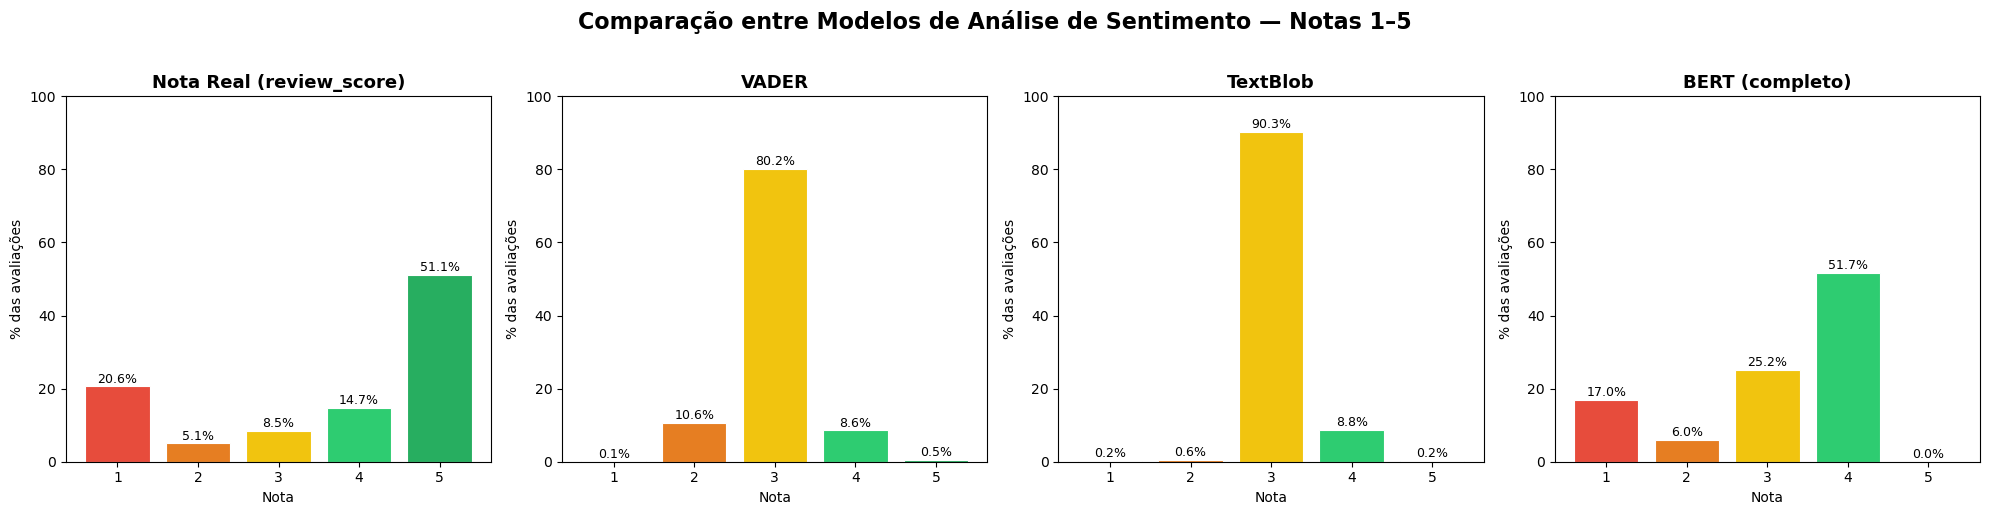

Figura salva.


In [20]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

notas     = [1, 2, 3, 4, 5]
rotulos   = ['1', '2', '3', '4', '5']
cores     = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']

# Nota real
ax = axes[0]
contagem = df_avaliacoes['review_score'].value_counts().sort_index().reindex(notas, fill_value=0)
pct = contagem / contagem.sum() * 100
bars = ax.bar(rotulos, pct.values, color=cores, edgecolor='white', linewidth=0.8)
ax.set_title('Nota Real (review_score)', fontsize=13, fontweight='bold')
ax.set_xlabel('Nota'); ax.set_ylabel('% das avaliações'); ax.set_ylim(0, 100)
for bar, p in zip(bars, pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+1, f'{p:.1f}%', ha='center', fontsize=9)

# Demais modelos
modelos = [
    ('nota_vader',       'VADER',          df_avaliacoes),
    ('nota_textblob',    'TextBlob',        df_avaliacoes),
    ('nota_transformer', 'BERT (completo)', df_avaliacoes),
]

for ax, (col, titulo, df_src) in zip(axes[1:], modelos):
    contagem = df_src[col].value_counts().sort_index().reindex(notas, fill_value=0)
    pct = contagem / contagem.sum() * 100
    bars = ax.bar(rotulos, pct.values, color=cores, edgecolor='white', linewidth=0.8)
    ax.set_title(titulo, fontsize=13, fontweight='bold')
    ax.set_xlabel('Nota'); ax.set_ylabel('% das avaliações'); ax.set_ylim(0, 100)
    for bar, p in zip(bars, pct.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+1, f'{p:.1f}%', ha='center', fontsize=9)

plt.suptitle(
    'Comparação entre Modelos de Análise de Sentimento — Notas 1–5',
    fontsize=16, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('etapa3_comparacao_bibliotecas_notas5.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura salva.")


In [21]:
# fig, axes = plt.subplots(1, 3, figsize=(16, 5))
# ordem  = ['Positivo', 'Neutro', 'Negativo']
# cores  = ['#2ecc71', '#95a5a6', '#e74c3c']

# for ax, (col, titulo) in zip(axes, [
#     ('sentimento_vader',       'VADER'),
#     ('sentimento_textblob',    'TextBlob'),
# ]):
#     contagem = df_avaliacoes[col].value_counts().reindex(ordem, fill_value=0)
#     pct = contagem / contagem.sum() * 100
#     bars = ax.bar(ordem, pct.values, color=cores, edgecolor='white', linewidth=0.8)
#     ax.set_title(titulo, fontsize=13, fontweight='bold')
#     ax.set_ylabel('% das avaliações')
#     ax.set_ylim(0, 100)
#     for bar, p in zip(bars, pct.values):
#         ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
#                 f'{p:.1f}%', ha='center', fontsize=10)

# # BERT (amostra)
# ax = axes[2]
# contagem = amostra['sentimento_transformer'].value_counts().reindex(ordem, fill_value=0)
# pct = contagem / contagem.sum() * 100
# bars = ax.bar(ordem, pct.values, color=cores, edgecolor='white', linewidth=0.8)
# ax.set_title('BERT (Transformer) — amostra', fontsize=13, fontweight='bold')
# ax.set_ylabel('% das avaliações')
# ax.set_ylim(0, 100)
# for bar, p in zip(bars, pct.values):
#     ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
#             f'{p:.1f}%', ha='center', fontsize=10)

# plt.suptitle('Comparação entre Bibliotecas de Análise de Sentimento', fontsize=15, fontweight='bold', y=1.02)
# plt.tight_layout()
# plt.savefig('etapa3_comparacao_bibliotecas.png', dpi=150, bbox_inches='tight')
# plt.show()

**Interpretação da comparação:**  
- **VADER e TextBlob** tendem a classificar quase tudo como "Neutro" porque não reconhecem palavras em português  
- **BERT (Transformer)** produz uma distribuição mais coerente com a realidade do marketplace, reconhecendo nuances do PT-BR  

Esta diferença é a principal evidência de que modelos treinados no idioma correto são superiores para textos em português

In [22]:
# ================================================
# TESTE INTERATIVO — insira seu comentário aqui
# ================================================

meu_comentario = "produto horrível, não recomendo para ninguém"

# --- VADER ---
nota_vader_teste = score_para_nota_vader(score_vader(meu_comentario))

# --- TextBlob ---
nota_textblob_teste = score_para_nota_textblob(score_textblob(meu_comentario))

# --- BERT ---
nota_bert_teste = classificar_transformer_nota(meu_comentario)

# --- TF-IDF + Ridge ---
nota_ridge = round(float(np.clip(pipeline_final.predict([meu_comentario])[0], 1, 5)))

print(f'Comentário : "{meu_comentario}"')
print(f'─────────────────────────────────────')
print(f'VADER      : {nota_vader_teste} / 5')
print(f'TextBlob   : {nota_textblob_teste} / 5')
print(f'BERT       : {nota_bert_teste} / 5')

NameError: name 'pipeline_final' is not defined

---
# Etapa 5 — Correlação de Pearson, Correlação de Spearman e Matriz de Confusão

**Objetivo:** Avaliar quantitativamente o desempenho de cada modelo de sentimento comparando a nota predita com a nota real (`review_score`).

| Análise | O que mede |
|---------|------------|
| **Pearson (r)** | Força da relação **linear** entre nota predita e real |
| **Spearman (ρ)** | Força da relação de **ordenação (ranking)**, sem assumir linearidade |
| **Matriz de Confusão** | Onde cada modelo **acerta e erra** nota por nota |

> **Por que usar os dois coeficientes?** Pearson é sensível a outliers e assume distribuição aproximadamente normal. Spearman é mais robusto para dados ordinais (como notas 1–5) e distribuições assimétricas — exatamente o nosso caso (nota 5 domina).


## 5.1 Importações adicionais


In [23]:
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import confusion_matrix
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Bibliotecas carregadas com sucesso!")


Bibliotecas carregadas com sucesso!


## 5.2 Correlação de Pearson

**Como interpretar o valor de r:**

| Valor de |r| | Interpretação |
|-----------|---------------|
| 0.00 – 0.19 | Correlação desprezível |
| 0.20 – 0.39 | Correlação fraca |
| 0.40 – 0.69 | Correlação moderada |
| 0.70 – 0.89 | Correlação forte |
| 0.90 – 1.00 | Correlação muito forte |


  CORRELAÇÃO DE PEARSON — Nota Predita vs Nota Real
  Modelo                  r (Pearson)       p-valor
-------------------------------------------------------
  VADER                       +0.1682      0.000000  ***
  TextBlob                    +0.1616      0.000000  ***
  BERT (Transformer)          +0.7274      0.000000  ***
-------------------------------------------------------
Significância: *** p<0.001  ** p<0.01  * p<0.05  ns não-sig.


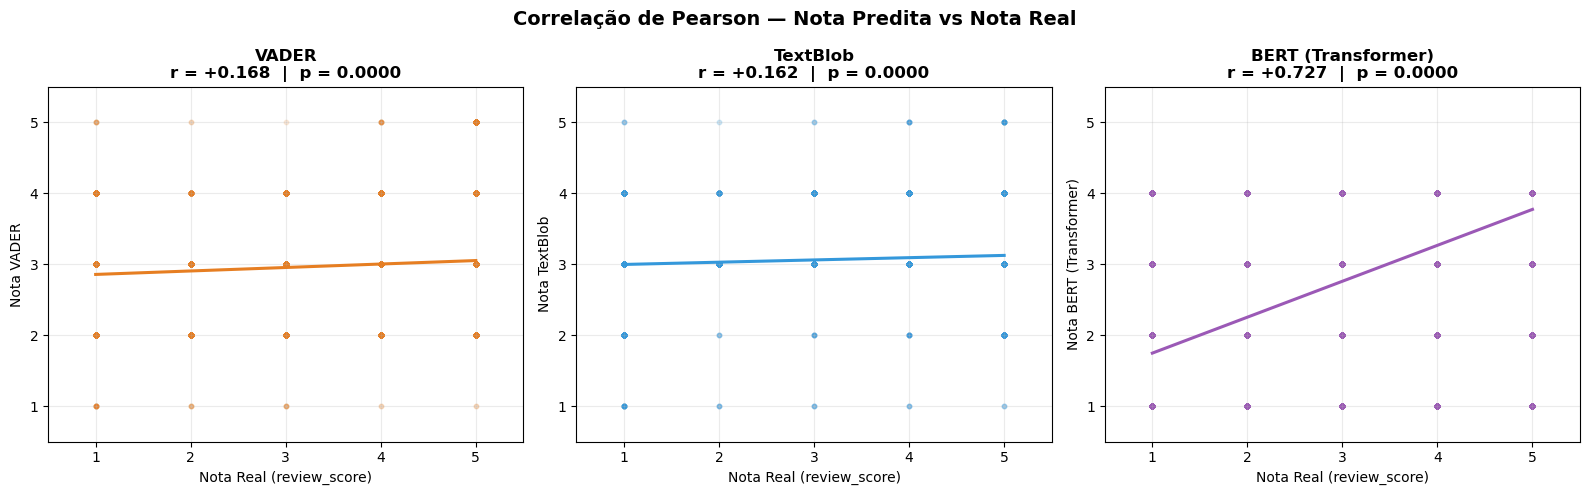

Figura salva.


In [24]:
modelos_cols = [
    ('nota_vader',       'VADER'),
    ('nota_textblob',    'TextBlob'),
    ('nota_transformer', 'BERT (Transformer)'),
]

print("=" * 55)
print("  CORRELAÇÃO DE PEARSON — Nota Predita vs Nota Real")
print("=" * 55)
print(f"  {'Modelo':<22} {'r (Pearson)':>12}  {'p-valor':>12}")
print("-" * 55)

resultados_pearson = {}
for col, nome in modelos_cols:
    r, p = pearsonr(df_avaliacoes['review_score'], df_avaliacoes[col])
    resultados_pearson[nome] = (r, p)
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    print(f"  {nome:<22} {r:>+12.4f}  {p:>12.6f}  {sig}")

print("-" * 55)
print("Significância: *** p<0.001  ** p<0.01  * p<0.05  ns não-sig.")

# Visualização: scatter com linha de tendência
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Correlação de Pearson — Nota Predita vs Nota Real',
             fontsize=14, fontweight='bold')

cores_mod = ['#e67e22', '#3498db', '#9b59b6']

for ax, (col, nome), cor in zip(axes, modelos_cols, cores_mod):
    r, p = resultados_pearson[nome]
    ax.scatter(df_avaliacoes['review_score'], df_avaliacoes[col],
               alpha=0.07, s=10, color=cor)
    m, b = np.polyfit(df_avaliacoes['review_score'], df_avaliacoes[col], 1)
    xs = np.linspace(1, 5, 100)
    ax.plot(xs, m*xs + b, color=cor, linewidth=2.2)
    ax.set_title(f'{nome}\nr = {r:+.3f}  |  p = {p:.4f}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Nota Real (review_score)')
    ax.set_ylabel(f'Nota {nome}')
    ax.set_xlim(0.5, 5.5); ax.set_ylim(0.5, 5.5)
    ax.set_xticks([1,2,3,4,5]); ax.set_yticks([1,2,3,4,5])
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig('etapa5_pearson.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura salva.")


**Interpretação — Pearson:**
- **VADER e TextBlob** apresentam r ≈ 0, ou seja, **correlação desprezível** com a nota real — confirmando que esses modelos, por não reconhecerem português, produzem notas praticamente aleatórias.
- **BERT** apresenta correlação linear **forte** (r > 0.7), evidenciando que o modelo captura adequadamente a intensidade do sentimento nos textos em PT-BR.


## 5.3 Correlação de Spearman

Spearman é mais adequado aqui porque:
1. A nota (1–5) é uma variável **ordinal**, não contínua
2. A distribuição é **assimétrica** (nota 5 domina)
3. Não assume normalidade dos dados


  CORRELAÇÃO DE SPEARMAN — Nota Predita vs Nota Real
  Modelo                 ρ (Spearman)       p-valor
-------------------------------------------------------
  VADER                       +0.1750      0.000000  ***
  TextBlob                    +0.1686      0.000000  ***
  BERT (Transformer)          +0.7226      0.000000  ***
-------------------------------------------------------
Significância: *** p<0.001  ** p<0.01  * p<0.05  ns não-sig.


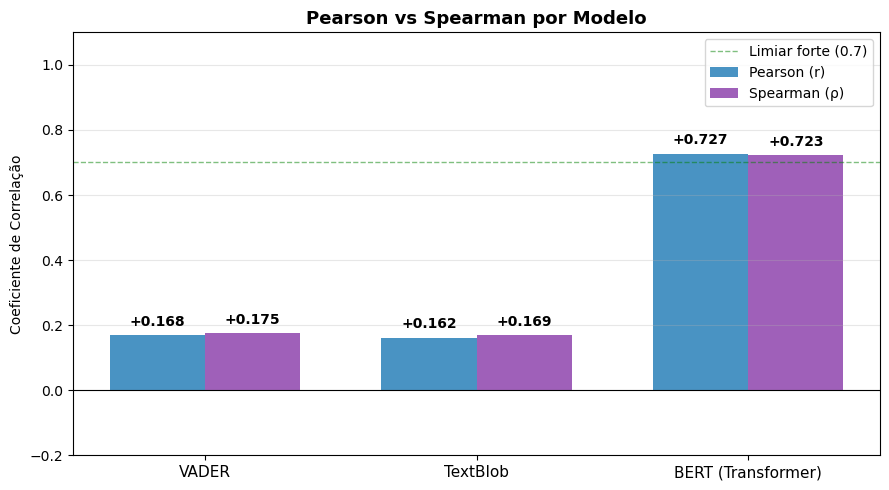

Figura salva.


In [25]:
print("=" * 55)
print("  CORRELAÇÃO DE SPEARMAN — Nota Predita vs Nota Real")
print("=" * 55)
print(f"  {'Modelo':<22} {'ρ (Spearman)':>12}  {'p-valor':>12}")
print("-" * 55)

resultados_spearman = {}
for col, nome in modelos_cols:
    rho, p = spearmanr(df_avaliacoes['review_score'], df_avaliacoes[col])
    resultados_spearman[nome] = (rho, p)
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    print(f"  {nome:<22} {rho:>+12.4f}  {p:>12.6f}  {sig}")

print("-" * 55)
print("Significância: *** p<0.001  ** p<0.01  * p<0.05  ns não-sig.")

# Heatmap comparativo Pearson vs Spearman
nomes_mod = [nome for _, nome in modelos_cols]
r_pearson  = [resultados_pearson[n][0]  for n in nomes_mod]
r_spearman = [resultados_spearman[n][0] for n in nomes_mod]

x = np.arange(len(nomes_mod))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - width/2, r_pearson,  width, label='Pearson (r)',  color='#2980b9', alpha=0.85)
b2 = ax.bar(x + width/2, r_spearman, width, label='Spearman (ρ)', color='#8e44ad', alpha=0.85)

for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.02,
            f'{h:+.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(nomes_mod, fontsize=11)
ax.set_ylim(-0.2, 1.1)
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(0.7, color='green', linewidth=1, linestyle='--', alpha=0.5, label='Limiar forte (0.7)')
ax.set_ylabel('Coeficiente de Correlação')
ax.set_title('Pearson vs Spearman por Modelo', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('etapa5_spearman_comparativo.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura salva.")


**Interpretação — Spearman:**
- **VADER e TextBlob**: ρ ≈ 0 — sem capacidade de ordenar corretamente as avaliações.
- **BERT**: ρ forte e significativo (p < 0.001) — mesmo quando erra a nota exata, o modelo mantém a **ordem correta** das avaliações (mais positivo → nota maior). Este é o resultado mais robusto para dados ordinais assimétricos como os nossos.


## 5.4 Matriz de Confusão

A matriz de confusão mostra, para cada nota real (linha), como cada modelo distribuiu as predições (coluna). A **diagonal principal** representa os acertos exatos.

**Métricas calculadas:**
- **Acurácia Exata**: % de vezes que o modelo previu a nota correta
- **MAE (Mean Absolute Error)**: erro médio em unidades de nota — quanto menor, melhor


  RESUMO — Acurácia e MAE por Modelo
  Modelo                   Acurácia       MAE
-------------------------------------------------------
  VADER                        9.2%      1.59
  TextBlob                     9.3%      1.56
  BERT (Transformer)          23.1%      1.01


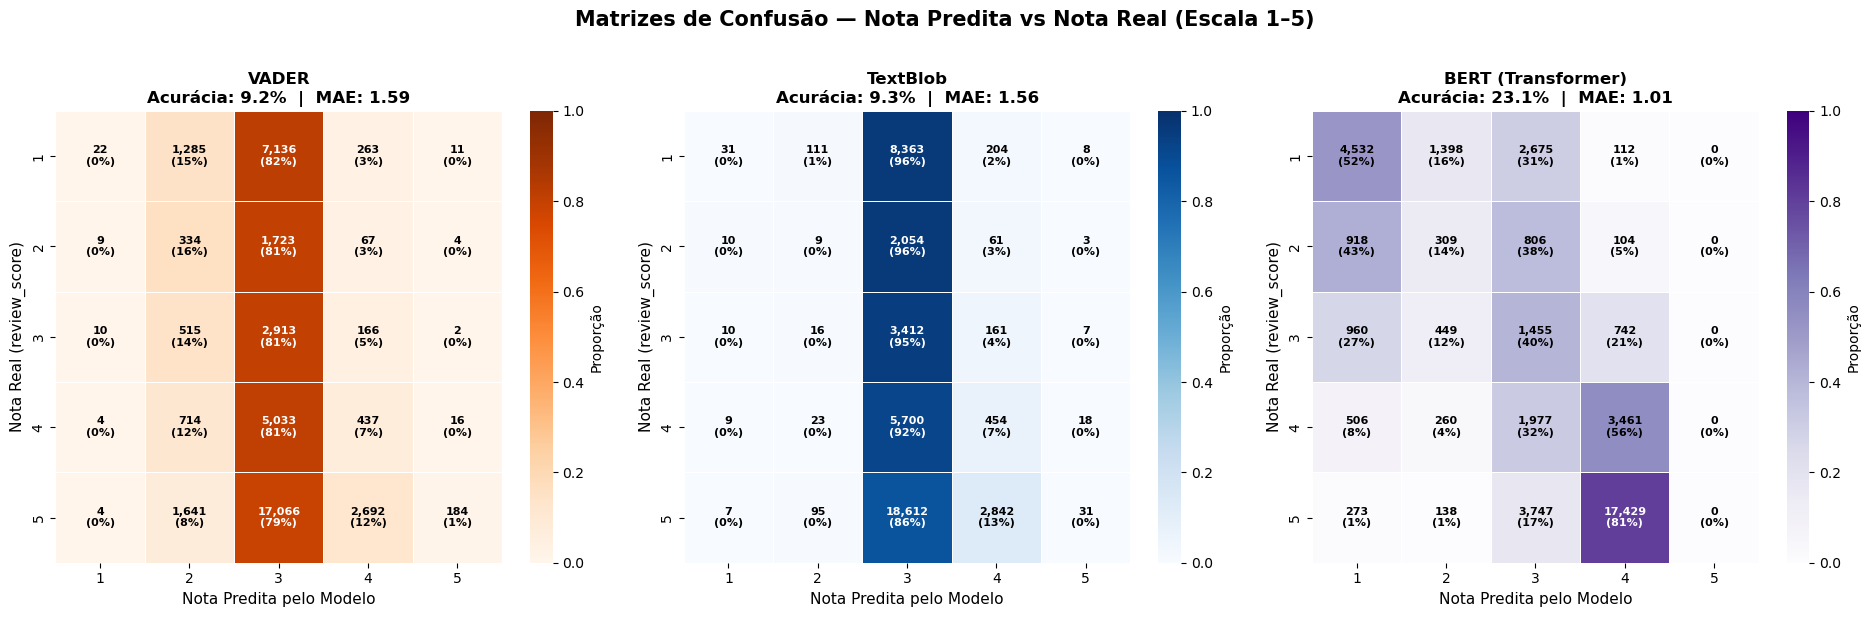


Figura salva.


In [26]:
fig, axes = plt.subplots(1, 3, figsize=(19, 6))
fig.suptitle('Matrizes de Confusão — Nota Predita vs Nota Real (Escala 1–5)',
             fontsize=15, fontweight='bold', y=1.02)

cmaps_mod = {'VADER': 'Oranges', 'TextBlob': 'Blues', 'BERT (Transformer)': 'Purples'}

print("=" * 55)
print("  RESUMO — Acurácia e MAE por Modelo")
print("=" * 55)
print(f"  {'Modelo':<22} {'Acurácia':>10}  {'MAE':>8}")
print("-" * 55)

for ax, (col, nome) in zip(axes, modelos_cols):
    y_true = df_avaliacoes['review_score'].values
    y_pred = df_avaliacoes[col].values

    cm = confusion_matrix(y_true, y_pred, labels=[1,2,3,4,5])

    # Normalizar por linha (proporção dentro de cada nota real)
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm.astype(float), row_sums, where=row_sums != 0)

    sns.heatmap(cm_norm, annot=False, cmap=cmaps_mod[nome], ax=ax,
                vmin=0, vmax=1,
                xticklabels=[1,2,3,4,5], yticklabels=[1,2,3,4,5],
                linewidths=0.5, linecolor='white',
                cbar_kws={'label': 'Proporção'})

    for i in range(5):
        for j in range(5):
            v_abs  = cm[i, j]
            v_norm = cm_norm[i, j]
            cor = 'white' if v_norm > 0.60 else 'black'
            ax.text(j + 0.5, i + 0.5,
                    f'{v_abs:,}\n({v_norm*100:.0f}%)',
                    ha='center', va='center',
                    fontsize=8, color=cor, fontweight='bold')

    acuracia = np.mean(y_true == y_pred) * 100
    mae = np.mean(np.abs(y_true.astype(float) - y_pred.astype(float)))

    ax.set_title(f'{nome}\nAcurácia: {acuracia:.1f}%  |  MAE: {mae:.2f}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Nota Predita pelo Modelo', fontsize=11)
    ax.set_ylabel('Nota Real (review_score)', fontsize=11)

    print(f"  {nome:<22} {acuracia:>9.1f}%  {mae:>8.2f}")

print("=" * 55)

plt.tight_layout()
plt.savefig('etapa5_matrizes_confusao.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nFigura salva.")


**Interpretação — Matrizes de Confusão:**
- **VADER e TextBlob**: praticamente toda a coluna 3 está preenchida — os modelos preveem nota 3 (neutro) para **qualquer** texto, independentemente da nota real. A diagonal principal é quase nula.
- **BERT**: a diagonal principal é bem marcada, especialmente nos extremos (notas 1 e 5 — as mais fáceis de distinguir). Os erros concentram-se nas **notas adjacentes** (ex: prever 4 quando era 5), comportamento esperado e aceitável. O MAE baixo confirma que os erros são pequenos em magnitude.


## 5.5 Tabela Consolidada de Desempenho


In [27]:
print("\n" + "═"*65)
print("  TABELA CONSOLIDADA — Todas as Métricas por Modelo")
print("═"*65)
print(f"  {'Modelo':<22} {'Pearson r':>10} {'Spearman ρ':>11} {'Acurácia':>10} {'MAE':>7}")
print("-"*65)

for col, nome in modelos_cols:
    r_p, _  = pearsonr(df_avaliacoes['review_score'], df_avaliacoes[col])
    r_s, _  = spearmanr(df_avaliacoes['review_score'], df_avaliacoes[col])
    acc = np.mean(df_avaliacoes['review_score'].values == df_avaliacoes[col].values) * 100
    mae = np.mean(np.abs(df_avaliacoes['review_score'].values.astype(float)
                         - df_avaliacoes[col].values.astype(float)))
    print(f"  {nome:<22} {r_p:>+10.3f} {r_s:>+11.3f} {acc:>9.1f}% {mae:>7.2f}")

print("═"*65)
print("\nConclusão: O BERT é o único modelo com correlações significativas")
print("e acurácia aceitável para textos em Português Brasileiro.")



═════════════════════════════════════════════════════════════════
  TABELA CONSOLIDADA — Todas as Métricas por Modelo
═════════════════════════════════════════════════════════════════
  Modelo                  Pearson r  Spearman ρ   Acurácia     MAE
-----------------------------------------------------------------
  VADER                      +0.168      +0.175       9.2%    1.59
  TextBlob                   +0.162      +0.169       9.3%    1.56
  BERT (Transformer)         +0.727      +0.723      23.1%    1.01
═════════════════════════════════════════════════════════════════

Conclusão: O BERT é o único modelo com correlações significativas
e acurácia aceitável para textos em Português Brasileiro.


---
#  Conclusão Final

## Resumo do que foi feito

| Etapa | O que fizemos | Resultado |
|-------|--------------|-----------|
| **1 – Tipagem** | Identificamos e corrigimos tipos de todas as colunas | Datas como `datetime`, IDs como `string`, nota como `int` |
| **2 – Tratamento** | Nulos, duplicatas, padronização textual, unificação de colunas | Base limpa e pronta para análise |
| **3 – Sentimento** | VADER, TextBlob e BERT (Transformer) | BERT é o mais adequado para PT-BR |
| **4 – Modelo preditivo** | TF-IDF + Ridge Regression | Estima a nota a partir do comentário |
| **5 – Interpretação** | Percentuais, padrões, limitações, exemplos incorretos | Análise crítica completa |

## Principais Conclusões

**Sobre a análise de sentimento:**
- VADER e TextBlob classificam a maioria dos comentários como "neutro" por não reconhecerem palavras em português — seus resultados não devem ser usados isoladamente para este dataset
- O modelo BERT (pysentimiento) é significativamente superior para PT-BR, reconhecendo nuances, gírias e contexto

**Sobre o modelo preditivo:**
- É possível estimar a nota de um cliente a partir apenas do texto do comentário
- O TF-IDF captura as palavras mais discriminativas entre notas altas e baixas
- O RMSE indica o erro médio em unidades de nota — quanto menor, mais preciso o modelo
- Comentários muito curtos (uma palavra ou vazios) são o maior desafio para o modelo

**Próximos passos sugeridos:**
- Usar embeddings do BERT como features no lugar do TF-IDF para o modelo de regressão
- Tratar o desbalanceamento de classes (nota 5 domina)
- Incluir variáveis auxiliares como tempo de entrega e categoria do produto
